In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('forPython.csv', sep = ';', decimal = ',')
df.head()

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
0,US,Before Thawing,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.9940,0.000,0.00000,0.0000,0.00600
1,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.210,0.07230,0.1570,0.27904
2,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.303,0.00055,0.0016,0.02240
3,After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.615,0.00120,0.0100,0.19740
4,US,Day 0,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.9970,0.000,0.00000,0.0000,0.00300


In [4]:
# Drop columns where sample is US 
df = df[df['Sample'] != 'US']
df.head()

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.2100,0.07230,0.1570,0.27904
2,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.3030,0.00055,0.0016,0.02240
3,After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.6150,0.00120,0.0100,0.19740
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.0011,0.00000,0.07320,0.00000,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.0010,0.00000,0.08180,0.00000,0.0493,0.0838,0.00200,0.0056,0.62000


In [5]:
df[df["Time"] == "Day 1"]

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
8,HSC no change,Day 1,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
9,HSC change 1 of 2,Day 1,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [6]:
df_day1 = df[df["Time"] == "Day 1"]
df_day1_cDC1_nochange = df_day1[df_day1["Sample"] == "cDC1 no change"]
df_day1_cDC1_change_everyday = df_day1[df_day1["Sample"] == "cDC1 change eveyday"]
df_day1_HSC_nochange = df_day1[df_day1["Sample"] == "HSC no change"]
df_day1_HSC_change1of2 = df_day1[df_day1["Sample"] == "HSC change 1 of 2"]


In [7]:
def split_by_day (dataframe):
    sample_days = {}
    for day in dataframe["Time"].unique():
        sample_days[day] = dataframe[dataframe["Time"] == day]
    return sample_days

In [8]:
def split_by_sample(df):
    sample_dict = {}
    for sample_name in df["Sample"].unique():
        sample_dict[sample_name] = df[df["Sample"] == sample_name]

    return sample_dict


In [9]:
results_by_day = split_by_day(df)
results_by_day['Day 1']

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
8,HSC no change,Day 1,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
9,HSC change 1 of 2,Day 1,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [10]:
samples_day1 = split_by_sample(results_by_day['Day 1'])
samples_day1["cDC1 change eveyday"]

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.0041,0.001,0.0,0.0818,0.0,0.0493,0.0838,0.002,0.0056,0.62


<Figure size 1000x600 with 0 Axes>

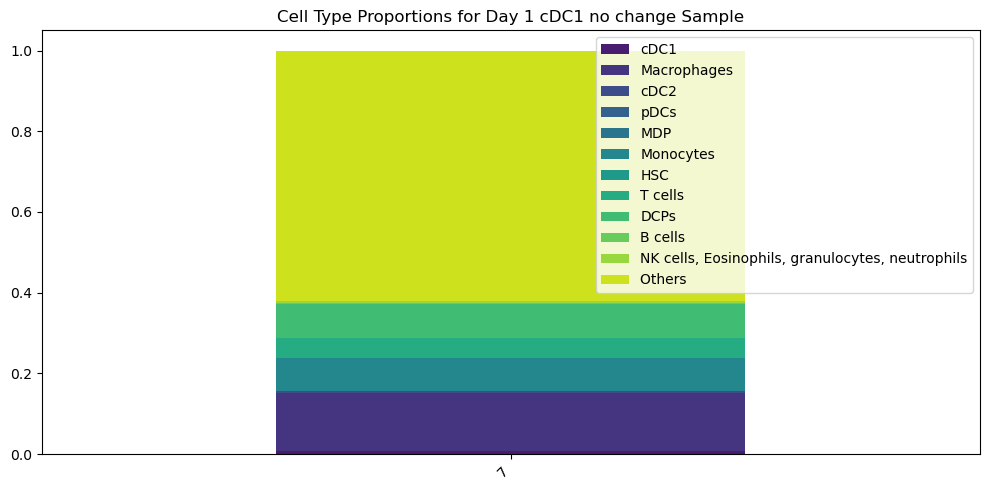

In [12]:
# Plot stacked bar chart of Cell Type proportions for Day 1 cDC1 no change sample
cell_types = [
    "cDC1", "Macrophages", "cDC2", "pDCs", "MDP", "Monocytes",
    "HSC", "T cells", "DCPs", "B cells",
    "NK cells, Eosinophils, granulocytes, neutrophils",
    "Others"
]

proportions = samples_day1["cDC1 change eveyday"].iloc[:, 2:]
proportions

proportions_plot = proportions.melt(var_name='Cell Type', value_name='Proportion')
proportions_plot
plt.figure(figsize=(10, 6))
proportions.plot(kind='bar', stacked=True, figsize=(10,5), color=sns.color_palette('viridis', n_colors=len(cell_types)))
plt.title('Cell Type Proportions for Day 1 cDC1 no change Sample')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('day1_cDC1_nochange_proportions.png')
plt.show()